In [9]:
# TRAINING FUNCTIONS

import numpy as np

def generate_parity_data(num_bits=4):
    """
    Generate all 2^n binary inputs and their parity labels.
    Label = 1 if an input contains an odd number of 1s, else 0.
    """
    num_samples = 2 ** num_bits
    inputs = np.array([
        [ (i >> bit) & 1 for bit in range(num_bits) ]
        for i in range(num_samples)
    ])
    labels = (inputs.sum(axis=1, keepdims=True) % 2)
    return inputs, labels

def logistic_sigmoid(x):
    """Logistic sigmoid activation function with 'a = 1'."""
    return 1 / (1 + np.exp(-x))

def logistic_sigmoid_derivative(y):
    """Derivative of the sigmoid."""
    return y * (1 - y)

def initialize_perceptron(num_inputs=4, num_hidden=4, num_outputs=1, seed=0):
    """Randomly initialize weights and biases in [-1, 1]."""
    rng = np.random.default_rng(seed)
    weights_input_to_hidden  = rng.uniform(-1, 1, size=(num_hidden, num_inputs))
    bias_hidden        = rng.uniform(-1, 1, size=(num_hidden,))
    weights_hidden_to_output = rng.uniform(-1, 1, size=(num_outputs, num_hidden))
    bias_output        = rng.uniform(-1, 1, size=(num_outputs,))
    return weights_input_to_hidden, bias_hidden, weights_hidden_to_output, bias_output

def predict_labels(inputs, weights_input_to_hidden, bias_hidden, weights_hidden_to_output, bias_output):
    """Compute predictions for all input patterns."""
    hidden_output = logistic_sigmoid(inputs @ weights_input_to_hidden.T + bias_hidden)
    predictions = logistic_sigmoid(hidden_output @ weights_hidden_to_output.T + bias_output)
    return predictions

def train_parity_perceptron(inputs, labels, eta=0.05, beta=0.0, max_epochs=250_000, stopping_threshold=0.05, seed=0):
    """Train a two-layer perceptron (4-4-1 network) to solve 4-bit parity problem."""
    # Initialize weights and biases
    weights_input_to_hidden, bias_hidden, weights_hidden_to_output, bias_output = initialize_perceptron(seed=seed)

    # Initialize momentum terms
    momentum_weights_input_to_hidden  = np.zeros_like(weights_input_to_hidden)
    momentum_bias_hidden              = np.zeros_like(bias_hidden)
    momentum_weights_hidden_to_output = np.zeros_like(weights_hidden_to_output)
    momentum_bias_output              = np.zeros_like(bias_output)

    learning_curve = []

    for epoch in range(1, max_epochs + 1):
        for i in range(len(inputs)):
            input = inputs[i]
            expected_output = labels[i]

            # Forward pass
            hidden_input     = weights_input_to_hidden @ input + bias_hidden
            hidden_output    = logistic_sigmoid(hidden_input)
            output_input     = weights_hidden_to_output @ hidden_output + bias_output
            predicted_output = logistic_sigmoid(output_input)

            # Backpropagation
            # Calculate errors by layer
            error_output_layer = logistic_sigmoid_derivative(predicted_output) * (predicted_output - expected_output)
            error_hidden_layer = logistic_sigmoid_derivative(hidden_output) * (weights_hidden_to_output.T @ error_output_layer)

            # Calculate gradients
            gradient_weights_hidden_to_output = np.outer(error_output_layer, hidden_output)
            gradient_bias_output              = error_output_layer.squeeze()
            gradient_weights_input_to_hidden  = np.outer(error_hidden_layer, input)
            gradient_bias_hidden              = error_hidden_layer

            # Momentum updates
            momentum_weights_hidden_to_output = beta * momentum_weights_hidden_to_output - eta * gradient_weights_hidden_to_output
            momentum_bias_output              = beta * momentum_bias_output  - eta * gradient_bias_output
            momentum_weights_input_to_hidden  = beta * momentum_weights_input_to_hidden - eta * gradient_weights_input_to_hidden
            momentum_bias_hidden              = beta * momentum_bias_hidden  - eta * gradient_bias_hidden

            # Parameter updates
            weights_hidden_to_output += momentum_weights_hidden_to_output
            bias_output              += momentum_bias_output
            weights_input_to_hidden  += momentum_weights_input_to_hidden
            bias_hidden              += momentum_bias_hidden

        # Check stopping criteria
        predictions = predict_labels(inputs, weights_input_to_hidden, bias_hidden, weights_hidden_to_output, bias_output)
        max_error = np.max(np.abs(labels - predictions))
        learning_curve.append(max_error)

        if np.all(np.abs(labels - predictions) <= stopping_threshold):
            break

    return weights_input_to_hidden, bias_hidden, weights_hidden_to_output, bias_output, epoch, learning_curve

In [10]:
# RUNNING & PLOTTING FUNCTIONS

import matplotlib.pyplot as plt

def run_parity_experiment(inputs, labels, etas=np.arange(0.05, 0.51, 0.05), beta=0.0, seed=0):
    results = {}
    for eta in etas:
        *_, epochs, learning_curve = train_parity_perceptron(inputs, labels, eta=eta, beta=beta, seed=seed)
        results[eta] = {'epochs': epochs, 'learning_curve': learning_curve}
    return results

def plot_curves(results, title):
    for eta in sorted(results.keys()):
        curve = results[eta]['learning_curve']
        plt.plot(curve, label=f"eta={eta:4.2f} (ep={results[eta]['epochs']})")
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Max Error (across all 4-bit strings)')
    plt.title(title)
    plt.legend(ncol=2, fontsize='small')
    plt.grid(True)
    plt.show()

eta   | epochs
------|--------
 0.05 | 33088
 0.10 | 16597
 0.15 | 11247
 0.20 | 8861
 0.25 | 9328
 0.30 | 10695
 0.35 | 10430
 0.40 | 26516
 0.45 | 26046
 0.50 | 25396


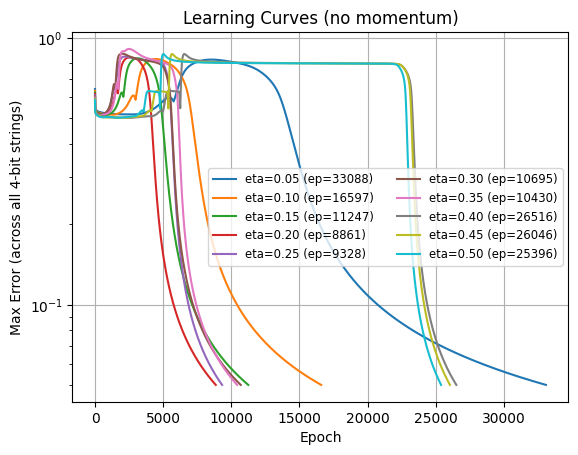

In [11]:
# RUN WITH NO MOMENTUM (beta=0.0)

inputs, labels = generate_parity_data()
results = run_parity_experiment(inputs, labels)

print("eta   | epochs")
print("------|--------")
for eta in sorted(results.keys()):
    print(f"{eta:5.2f} | {results[eta]['epochs']}")

plot_curves(results, "Learning Curves (no momentum)")

### Learning Rate (Eta) Influence on Convergence

The extremes of the eta range (0.05 and 0.5) tend to take more epochs to converge. For example, 0.05 takes the most amount of epochs, followed by 0.4, 0.45, and 0.5. The etas in the middle of the range (0.2 and 0.25) take the shortest amount of time to converge. There is a not too small, not too large sweet spot for learning rate which produces optimal convergence results to speed up training for the 4-4-1 parity perceptron. This can be observed in the table and convergence plot above.

Note that the seed (which randomizes the starting weights and biases), the choice to use Batch Gradient Descent (the entire dataset is used in each epoch) as well as the error threshold (set to 0.05) also have an effect on these epoch outputs. A larger threshold would mean a faster convergence, for example.

eta   | epochs
------|--------
 0.05 | 3331
 0.10 | 1691
 0.15 | 1181
 0.20 | 1487
 0.25 | 3401
 0.30 | 31922
 0.35 | 827
 0.40 | 128542
 0.45 | 10122
 0.50 | 86140


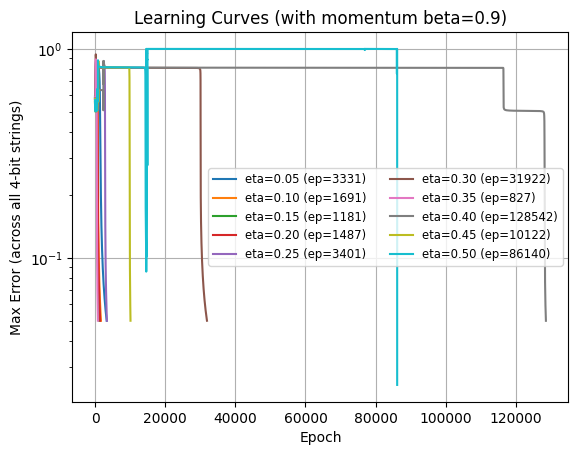

In [12]:
# RUN WITH MOMENTUM (beta=0.9)

inputs, labels = generate_parity_data()
results = run_parity_experiment(inputs, labels, beta=0.9)

print("eta   | epochs")
print("------|--------")
for eta in sorted(results.keys()):
    print(f"{eta:5.2f} | {results[eta]['epochs']}")

plot_curves(results, "Learning Curves (with momentum beta=0.9)")


### Momentum Term's Effect on Training Speed

The momentum term reduces time elapsed during training for most of the low to medium learning rates, minus a few outliers. Referencing the table and plot above, the momentum term greatly reduces epochs to convergence on learning rates which already produced a lower number of epochs to converge relative to other learning rates. Once again, the middle of the eta range (0.15 and 0.20) have the lowest epochs to convergence. However, some outliers like 0.30 and 0.40 actually take a larger number of epochs, meaning the momentum term has a negative effect with these learning rates.